<a href="https://colab.research.google.com/github/cibelerusso/FundamentosemCienciasdeDados/blob/main/Notebooks/Fundamentos_em_Ciencias_de_Dados_Aula_14_Valida%C3%A7%C3%A3o_de_modelos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Validação de Modelos e Validação Cruzada

## 5500004 Fundamentos em Ciências de Dados

## Profa. Cibele Russo - ICMC USP

Fonte principal: MOREIRA, João Mendes; CARVALHO, André C. P. L. F. de; HORVÁTH, Tomáš. **A General Introduction to Data Analytics**. 1. ed. Hoboken, NJ: John Wiley & Sons, Inc., 2019.

Notebook criado com apoio de ferramentas de IA generativa: NotebookLM e ChatGPT.

Dados utilizados neste notebook: base **Iris**, disponível no pacote `scikit-learn`.


# Aula: Validação de Modelos

O objetivo principal de um modelo preditivo é apresentar bom desempenho em **dados novos**, isto é, em observações que não foram usadas no ajuste do modelo.

Nesta aula, estudaremos:

- o problema de avaliar um modelo usando os mesmos dados do treinamento;
- o método **holdout**, com separação treino-teste;
- a **validação cruzada k-fold**;
- a **validação cruzada estratificada**;
- o caso especial **leave-one-out**;
- o uso correto de **pipelines** para evitar vazamento de informação (*data leakage*);
- uma aplicação completa com a base **Iris**.

A ideia central é responder à pergunta:

> Como estimar, da forma mais confiável possível, o desempenho de um modelo em dados que ele ainda não viu?


## 1. Carregamento das bibliotecas

Vamos usar bibliotecas para manipulação de dados, visualização, modelagem estatística e avaliação de modelos.


In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    LeaveOneOut,
    cross_val_score,
    cross_validate,
    cross_val_predict,
    validation_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

sns.set_theme(style="whitegrid")
np.random.seed(42)


/home/cibele/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


# 2. Conjunto de dados Iris

A base **Iris** é um conjunto clássico de classificação. O objetivo é prever a espécie da flor a partir de medidas das sépalas e pétalas.

| Variável | Descrição |
|---|---|
| `sepal length (cm)` | comprimento da sépala |
| `sepal width (cm)` | largura da sépala |
| `petal length (cm)` | comprimento da pétala |
| `petal width (cm)` | largura da pétala |
| `target` | espécie da flor |

A variável resposta tem três classes:

- `setosa`;
- `versicolor`;
- `virginica`.


In [ ]:
iris = load_iris(as_frame=True)

df = iris.frame.copy()
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [ ]:
print("Dimensões da base:", df.shape)
print("Variáveis explicativas:", list(iris.feature_names))
print("Classes:", list(iris.target_names))

df["species"].value_counts()


Dimensões da base: (150, 6)
Variáveis explicativas: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa', 'versicolor', 'virginica']


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

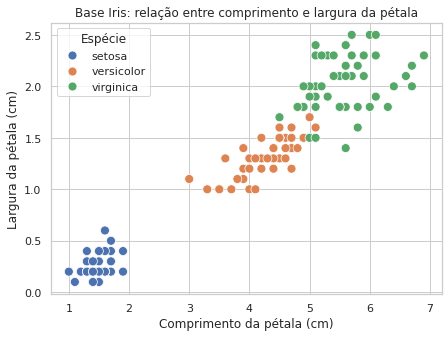

In [ ]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="species",
    s=80
)
plt.title("Base Iris: relação entre comprimento e largura da pétala")
plt.xlabel("Comprimento da pétala (cm)")
plt.ylabel("Largura da pétala (cm)")
plt.legend(title="Espécie")
plt.show()


# 3. Por que validar modelos?

Um modelo pode apresentar excelente desempenho nos dados de treinamento e, ainda assim, falhar em dados novos.

Isso ocorre porque o modelo pode ter aprendido não apenas os padrões gerais dos dados, mas também detalhes específicos, ruídos e particularidades da amostra de treinamento. Esse fenômeno é chamado de **sobreajuste** (*overfitting*).

## Erro de treinamento versus erro de generalização

- **Erro de treinamento:** calculado nos dados usados para ajustar o modelo.
- **Erro de teste ou validação:** calculado em dados não usados no ajuste.
- **Erro de generalização:** erro esperado em novos dados da população.

Na prática, não observamos diretamente o erro de generalização. Por isso usamos estratégias de validação.


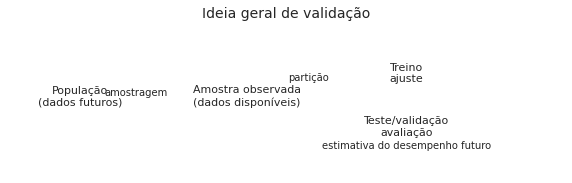

In [ ]:
# Esquema conceitual: amostra, treino, validação/teste e população
fig, ax = plt.subplots(figsize=(10, 2.8))
ax.axis("off")

boxes = [
    (0.03, 0.35, 0.20, 0.35, "População\n(dados futuros)"),
    (0.32, 0.35, 0.22, 0.35, "Amostra observada\n(dados disponíveis)"),
    (0.64, 0.55, 0.15, 0.25, "Treino\najuste"),
    (0.64, 0.20, 0.15, 0.25, "Teste/validação\navaliação"),
]

for x, y, w, h, text in boxes:
    rect = plt.Rectangle((x, y), w, h, fill=False, linewidth=2)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=11)

ax.annotate("amostragem", xy=(0.32, 0.53), xytext=(0.23, 0.53), arrowprops=dict(arrowstyle="->", lw=2), ha="center")
ax.annotate("partição", xy=(0.64, 0.63), xytext=(0.54, 0.63), arrowprops=dict(arrowstyle="->", lw=2), ha="center")
ax.annotate("estimativa do desempenho futuro", xy=(0.23, 0.35), xytext=(0.715, 0.18), arrowprops=dict(arrowstyle="->", lw=2, linestyle="--"), ha="center")

plt.title("Ideia geral de validação", fontsize=14)
plt.show()


# 4. Avaliação ingênua: treinar e testar nos mesmos dados

Uma forma inadequada de avaliar um modelo é treiná-lo usando todos os dados e, em seguida, medir a acurácia nos mesmos dados.

Esse procedimento tende a produzir uma estimativa otimista, pois o modelo já viu as observações usadas na avaliação.


In [ ]:
X = iris.data
y = iris.target


In [ ]:
modelo_knn = Pipeline([
    ("padronizacao", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=3))
])

modelo_knn.fit(X, y)
y_pred_treino = modelo_knn.predict(X)

acc_treino = accuracy_score(y, y_pred_treino)
print(f"Acurácia avaliada nos próprios dados de treinamento: {acc_treino:.4f}")


Acurácia avaliada nos próprios dados de treinamento: 0.9533


Esse valor não deve ser interpretado como desempenho esperado em dados novos. Ele mede apenas o quanto o modelo consegue reproduzir os próprios dados usados no ajuste.


# 5. Método Holdout

O método **holdout** divide a amostra em dois subconjuntos:

- **conjunto de treinamento:** usado para ajustar o modelo;
- **conjunto de teste:** usado para avaliar o modelo ajustado.

Uma divisão comum é usar 70% ou 80% dos dados para treino e o restante para teste.

## Limitações do holdout

- O resultado pode depender muito da partição escolhida.
- Em bases pequenas, separar dados para teste reduz a quantidade de informação disponível para o treinamento.
- Uma única divisão pode ser pouco representativa.


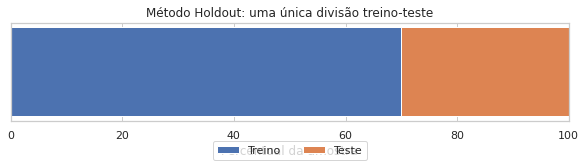

In [ ]:
# Esquema do método holdout
n = 100
train_size = 70

fig, ax = plt.subplots(figsize=(10, 1.8))
ax.barh(0, train_size, left=0, label="Treino")
ax.barh(0, n - train_size, left=train_size, label="Teste")
ax.set_xlim(0, 100)
ax.set_yticks([])
ax.set_xlabel("Percentual da amostra")
ax.set_title("Método Holdout: uma única divisão treino-teste")
ax.legend(loc="upper center", ncol=2, bbox_to_anchor=(0.5, -0.15))
plt.show()


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Tamanho do treino:", X_train.shape[0])
print("Tamanho do teste:", X_test.shape[0])


Tamanho do treino: 105
Tamanho do teste: 45


In [ ]:
modelo_holdout = Pipeline([
    ("padronizacao", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

modelo_holdout.fit(X_train, y_train)
y_pred = modelo_holdout.predict(X_test)

print(f"Acurácia no teste: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-score macro no teste: {f1_score(y_test, y_pred, average='macro'):.4f}")


Acurácia no teste: 0.9111
F1-score macro no teste: 0.9095


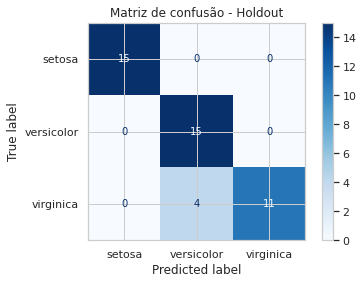

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap="Blues")
plt.title("Matriz de confusão - Holdout")
plt.show()


In [ ]:
print(classification_report(y_test, y_pred, target_names=iris.target_names))


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.79      1.00      0.88        15
   virginica       1.00      0.73      0.85        15

    accuracy                           0.91        45
   macro avg       0.93      0.91      0.91        45
weighted avg       0.93      0.91      0.91        45



# 6. O problema da variabilidade no holdout

Duas divisões diferentes dos mesmos dados podem produzir desempenhos diferentes.

Vamos repetir o holdout várias vezes, mudando a semente aleatória, para observar a variabilidade da estimativa de desempenho.


In [ ]:
resultados_holdout = []

for seed in range(50):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.30,
        random_state=seed,
        stratify=y
    )
    modelo = Pipeline([
        ("padronizacao", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=5))
    ])
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    resultados_holdout.append(accuracy_score(y_test, pred))

resultados_holdout = np.array(resultados_holdout)

print(f"Média das acurácias: {resultados_holdout.mean():.4f}")
print(f"Desvio padrão: {resultados_holdout.std():.4f}")
print(f"Mínimo: {resultados_holdout.min():.4f}")
print(f"Máximo: {resultados_holdout.max():.4f}")


Média das acurácias: 0.9462
Desvio padrão: 0.0278
Mínimo: 0.8889
Máximo: 1.0000


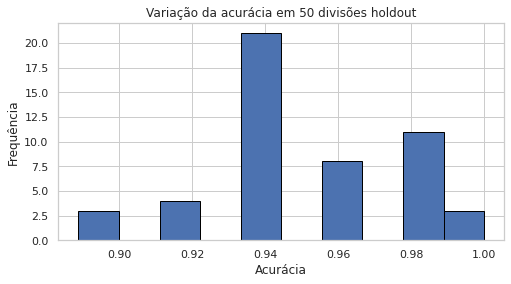

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(resultados_holdout, bins=10, edgecolor="black")
plt.xlabel("Acurácia")
plt.ylabel("Frequência")
plt.title("Variação da acurácia em 50 divisões holdout")
plt.show()


# 7. Validação cruzada k-fold

Para reduzir a dependência de uma única partição, usamos a **validação cruzada k-fold**.

## Como funciona

1. O conjunto de dados é dividido em `k` subconjuntos, chamados de **folds**.
2. O modelo é treinado `k` vezes.
3. Em cada rodada, um fold é usado como teste e os demais como treino.
4. O desempenho final é a média dos desempenhos obtidos nos `k` testes.

No k-fold, cada observação é usada para teste exatamente uma vez e para treinamento `k - 1` vezes.


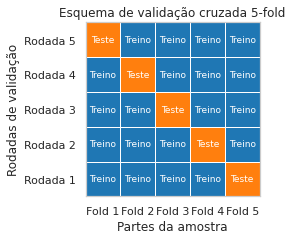

In [ ]:
def desenhar_kfold(k=5):
    fig, ax = plt.subplots(figsize=(15, 3.2))
    ax.set_xlim(0, k)
    ax.set_ylim(0, k)
    ax.set_xticks(np.arange(k) + 0.5)
    ax.set_xticklabels([f"Fold {i+1}" for i in range(k)])
    ax.set_yticks(np.arange(k) + 0.5)
    ax.set_yticklabels([f"Rodada {i+1}" for i in range(k)])
    ax.set_xlabel("Partes da amostra")
    ax.set_ylabel("Rodadas de validação")
    ax.set_title(f"Esquema de validação cruzada {k}-fold")

    for i in range(k):
        for j in range(k):
            color = "tab:orange" if i == j else "tab:blue"
            label = "Teste" if i == j else "Treino"
            rect = plt.Rectangle((j, k-1-i), 1, 1, facecolor=color, edgecolor="white")
            ax.add_patch(rect)
            ax.text(j + 0.5, k-1-i + 0.5, label, ha="center", va="center", color="white", fontsize=9)

    ax.set_aspect("equal")
    plt.show()

desenhar_kfold(k=5)


## Escolha do valor de `k`

Um valor frequentemente usado é `k = 10`. Nesse caso, em cada rodada:

- 90% dos dados são usados no treinamento;
- 10% dos dados são usados no teste;
- todos os objetos aparecem no teste exatamente uma vez.

Valores pequenos de `k` reduzem o custo computacional, mas podem produzir estimativas mais variáveis. Valores grandes usam mais dados no treino em cada rodada, mas aumentam o número de ajustes do modelo.


In [ ]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

modelo_cv = Pipeline([
    ("padronizacao", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

scores = cross_val_score(modelo_cv, X, y, cv=kf, scoring="accuracy")

print("Acurácias por fold:")
print(np.round(scores, 4))
print(f"Acurácia média: {scores.mean():.4f}")
print(f"Desvio padrão: {scores.std():.4f}")


Acurácias por fold:
[1.     1.     1.     0.9333 1.     0.8667 0.8    1.     1.     0.9333]
Acurácia média: 0.9533
Desvio padrão: 0.0670


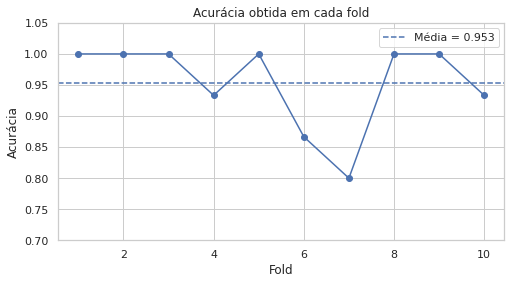

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(scores) + 1), scores, marker="o")
plt.axhline(scores.mean(), linestyle="--", label=f"Média = {scores.mean():.3f}")
plt.ylim(0.7, 1.05)
plt.xlabel("Fold")
plt.ylabel("Acurácia")
plt.title("Acurácia obtida em cada fold")
plt.legend()
plt.show()


# 8. Validação cruzada estratificada

Em problemas de classificação, é comum preservar a proporção das classes em cada fold. Esse procedimento é chamado de **k-fold estratificado**.

A estratificação é especialmente importante quando as classes são desbalanceadas, pois evita que algum fold fique com poucas observações de uma classe ou até sem determinada classe.

Na base Iris, as classes são perfeitamente balanceadas, mas ainda assim podemos usar `StratifiedKFold` como boa prática.


In [ ]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scores_strat = cross_val_score(modelo_cv, X, y, cv=skf, scoring="accuracy")

print("Acurácias por fold - StratifiedKFold:")
print(np.round(scores_strat, 4))
print(f"Acurácia média: {scores_strat.mean():.4f}")
print(f"Desvio padrão: {scores_strat.std():.4f}")


Acurácias por fold - StratifiedKFold:
[1.     1.     1.     0.9333 0.9333 0.8667 1.     1.     1.     0.8667]
Acurácia média: 0.9600
Desvio padrão: 0.0533


In [ ]:
# Verificando a composição das classes nos folds estratificados
linhas = []
for fold, (_, test_idx) in enumerate(skf.split(X, y), start=1):
    contagem = pd.Series(y[test_idx]).value_counts().sort_index()
    linhas.append({
        "fold": fold,
        "setosa": contagem.get(0, 0),
        "versicolor": contagem.get(1, 0),
        "virginica": contagem.get(2, 0)
    })

pd.DataFrame(linhas)


,fold,setosa,versicolor,virginica
0,1,5,5,5
1,2,5,5,5
2,3,5,5,5
3,4,5,5,5
4,5,5,5,5
5,6,5,5,5
6,7,5,5,5
7,8,5,5,5
8,9,5,5,5
9,10,5,5,5


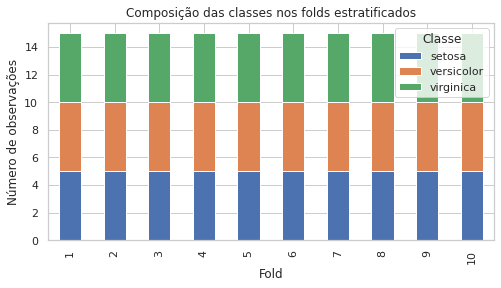

In [ ]:
fold_classes = pd.DataFrame(linhas).set_index("fold")

fold_classes.plot(kind="bar", stacked=True, figsize=(8, 4))
plt.xlabel("Fold")
plt.ylabel("Número de observações")
plt.title("Composição das classes nos folds estratificados")
plt.legend(title="Classe")
plt.show()


# 9. Validação cruzada com várias métricas

A função `cross_validate` permite calcular várias métricas ao mesmo tempo e também retornar tempos de ajuste e predição.

Como a base Iris possui três classes, usaremos médias **macro** para precisão, revocação e F1-score. A média macro calcula a métrica para cada classe e depois tira a média, dando o mesmo peso a todas as classes.


In [ ]:
metricas = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro"
}

resultado_cv = cross_validate(
    modelo_cv,
    X,
    y,
    cv=skf,
    scoring=metricas,
    return_train_score=True
)

resultado_cv_df = pd.DataFrame(resultado_cv)
resultado_cv_df


,fit_time,score_time,test_accuracy,train_accuracy,test_precision_macro,train_precision_macro,test_recall_macro,train_recall_macro,test_f1_macro,train_f1_macro
0,0.003759,0.009359,1.000000,0.940741,1.000000,0.940741,1.000000,0.940741,1.000000,0.940741
1,0.002734,0.007978,1.000000,0.955556,1.000000,0.956127,1.000000,0.955556,1.000000,0.955534
2,0.003302,0.008888,1.000000,0.955556,1.000000,0.956127,1.000000,0.955556,1.000000,0.955534
3,0.002621,0.008072,0.933333,0.970370,0.944444,0.970370,0.933333,0.970370,0.932660,0.970370
4,0.002721,0.007751,0.933333,0.962963,0.944444,0.963109,0.933333,0.962963,0.932660,0.962958
5,0.002668,0.007555,0.866667,0.970370,0.904762,0.970971,0.866667,0.970370,0.861111,0.970356
6,0.002571,0.008086,1.000000,0.955556,1.000000,0.955556,1.000000,0.955556,1.000000,0.955556
7,0.002787,0.007767,1.000000,0.948148,1.000000,0.948287,1.000000,0.948148,1.000000,0.948142
8,0.002634,0.008015,1.000000,0.955556,1.000000,0.955556,1.000000,0.955556,1.000000,0.955556
9,0.002735,0.007975,0.866667,0.970370,0.904762,0.970692,0.866667,0.970370,0.861111,0.970451


In [ ]:
resumo_metricas = resultado_cv_df[[
    "test_accuracy",
    "test_precision_macro",
    "test_recall_macro",
    "test_f1_macro"
]].agg(["mean", "std"]).T

resumo_metricas.columns = ["média", "desvio_padrão"]
resumo_metricas


,média,desvio_padrão
test_accuracy,0.960000,0.056218
test_precision_macro,0.969841,0.041120
test_recall_macro,0.960000,0.056218
test_f1_macro,0.958754,0.058345


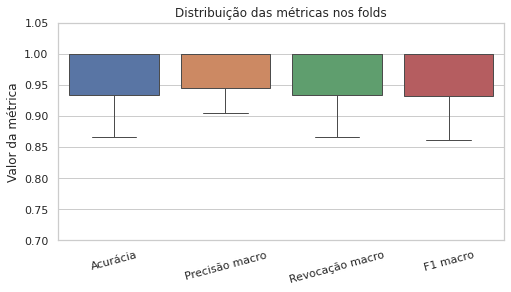

In [ ]:
metricas_teste = resultado_cv_df[[
    "test_accuracy",
    "test_precision_macro",
    "test_recall_macro",
    "test_f1_macro"
]].copy()

metricas_teste.columns = ["Acurácia", "Precisão macro", "Revocação macro", "F1 macro"]

plt.figure(figsize=(8, 4))
sns.boxplot(data=metricas_teste)
plt.ylabel("Valor da métrica")
plt.title("Distribuição das métricas nos folds")
plt.ylim(0.7, 1.05)
plt.xticks(rotation=15)
plt.show()


# 10. Predições por validação cruzada

A função `cross_val_predict` produz uma predição para cada observação, sempre usando um modelo que não foi treinado com aquela observação no conjunto de teste.

Isso permite construir uma matriz de confusão baseada em predições fora da amostra.


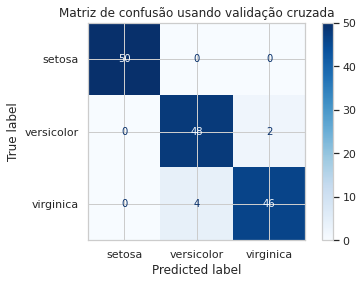

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       0.92      0.96      0.94        50
   virginica       0.96      0.92      0.94        50

    accuracy                           0.96       150
   macro avg       0.96      0.96      0.96       150
weighted avg       0.96      0.96      0.96       150



In [ ]:
y_pred_cv = cross_val_predict(modelo_cv, X, y, cv=skf)

cm_cv = confusion_matrix(y, y_pred_cv)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_cv, display_labels=iris.target_names)
disp.plot(cmap="Blues")
plt.title("Matriz de confusão usando validação cruzada")
plt.show()

print(classification_report(y, y_pred_cv, target_names=iris.target_names))


# 11. Comparando modelos com a mesma validação cruzada

A validação cruzada também pode ser usada para comparar algoritmos.

Vamos comparar três modelos:

- KNN;
- Regressão Logística;
- Árvore de Decisão.

Para uma comparação justa, todos os modelos serão avaliados usando os mesmos folds estratificados.


In [ ]:
modelos = {
    "KNN": Pipeline([
        ("padronizacao", StandardScaler()),
        ("modelo", KNeighborsClassifier(n_neighbors=5))
    ]),
    "Regressão Logística": Pipeline([
        ("padronizacao", StandardScaler()),
        ("modelo", LogisticRegression(max_iter=1000))
    ]),
    "Árvore de Decisão": DecisionTreeClassifier(random_state=42)
}

resultados_modelos = []

for nome, modelo in modelos.items():
    scores_modelo = cross_val_score(modelo, X, y, cv=skf, scoring="accuracy")
    for fold, score in enumerate(scores_modelo, start=1):
        resultados_modelos.append({"modelo": nome, "fold": fold, "accuracy": score})

resultados_modelos_df = pd.DataFrame(resultados_modelos)
resultados_modelos_df.head()


,modelo,fold,accuracy
0,KNN,1,1.000000
1,KNN,2,1.000000
2,KNN,3,1.000000
3,KNN,4,0.933333
4,KNN,5,0.933333


In [ ]:
resumo_modelos = resultados_modelos_df.groupby("modelo")["accuracy"].agg(["mean", "std", "min", "max"])
resumo_modelos.sort_values("mean", ascending=False)


,mean,std,min,max
modelo,,,,
KNN,0.960000,0.056218,0.866667,1.0
Regressão Logística,0.953333,0.054885,0.866667,1.0
Árvore de Decisão,0.933333,0.054433,0.866667,1.0


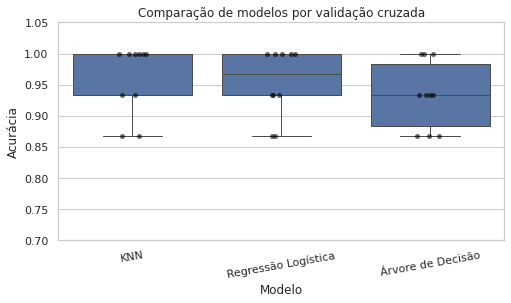

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=resultados_modelos_df, x="modelo", y="accuracy")
sns.stripplot(data=resultados_modelos_df, x="modelo", y="accuracy", color="black", alpha=0.6)
plt.xlabel("Modelo")
plt.ylabel("Acurácia")
plt.title("Comparação de modelos por validação cruzada")
plt.ylim(0.7, 1.05)
plt.xticks(rotation=10)
plt.show()


# 12. Escolha de hiperparâmetros por validação cruzada

Modelos de aprendizado de máquina possuem **hiperparâmetros**, isto é, escolhas feitas antes do treinamento.

No KNN, um hiperparâmetro importante é o número de vizinhos `n_neighbors`.

Vamos avaliar diferentes valores de `k` do KNN usando validação cruzada estratificada.


In [ ]:
valores_k = range(1, 31)
medias = []
desvios = []

for k in valores_k:
    modelo = Pipeline([
        ("padronizacao", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    scores_k = cross_val_score(modelo, X, y, cv=skf, scoring="accuracy")
    medias.append(scores_k.mean())
    desvios.append(scores_k.std())

resultado_k = pd.DataFrame({
    "n_neighbors": list(valores_k),
    "accuracy_mean": medias,
    "accuracy_std": desvios
})

resultado_k.sort_values("accuracy_mean", ascending=False).head(10)


,n_neighbors,accuracy_mean,accuracy_std
13,14,0.973333,0.032660
12,13,0.973333,0.032660
11,12,0.966667,0.044721
24,25,0.960000,0.044222
23,24,0.960000,0.044222
14,15,0.960000,0.053333
15,16,0.960000,0.053333
5,6,0.960000,0.044222
4,5,0.960000,0.053333
10,11,0.960000,0.053333


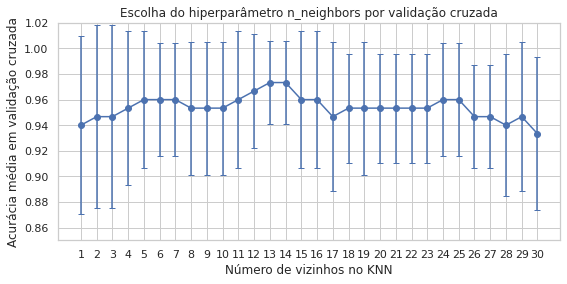

In [ ]:
plt.figure(figsize=(9, 4))
plt.errorbar(resultado_k["n_neighbors"], resultado_k["accuracy_mean"], yerr=resultado_k["accuracy_std"], marker="o", capsize=3)
plt.xlabel("Número de vizinhos no KNN")
plt.ylabel("Acurácia média em validação cruzada")
plt.title("Escolha do hiperparâmetro n_neighbors por validação cruzada")
plt.xticks(list(valores_k))
plt.ylim(0.85, 1.02)
plt.show()


## Curva de validação

A curva de validação compara o desempenho de treinamento e de validação para diferentes valores de um hiperparâmetro.

Ela ajuda a diagnosticar:

- **subajuste:** desempenho baixo tanto no treino quanto na validação;
- **sobreajuste:** desempenho alto no treino e menor na validação;
- **boa generalização:** desempenho alto e semelhante nos dois conjuntos.


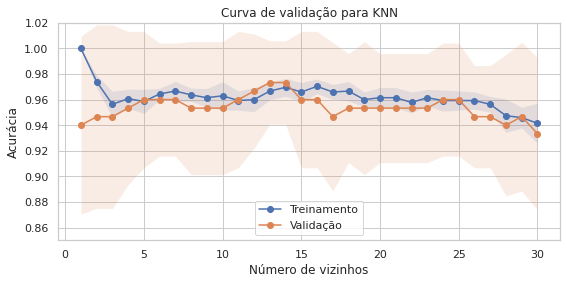

In [ ]:
param_range = np.arange(1, 31)

train_scores, test_scores = validation_curve(
    Pipeline([
        ("padronizacao", StandardScaler()),
        ("knn", KNeighborsClassifier())
    ]),
    X,
    y,
    param_name="knn__n_neighbors",
    param_range=param_range,
    cv=skf,
    scoring="accuracy"
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_std = test_scores.std(axis=1)

plt.figure(figsize=(9, 4))
plt.plot(param_range, train_mean, marker="o", label="Treinamento")
plt.plot(param_range, test_mean, marker="o", label="Validação")
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.15)
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.15)
plt.xlabel("Número de vizinhos")
plt.ylabel("Acurácia")
plt.title("Curva de validação para KNN")
plt.legend()
plt.ylim(0.85, 1.02)
plt.show()


# 13. Leave-one-out cross-validation

O **leave-one-out** é um caso especial do k-fold em que `k = n`, isto é, o número de folds é igual ao número de observações.

Em cada rodada:

- uma única observação é usada para teste;
- todas as demais são usadas para treinamento.

Essa técnica pode ser útil em bases muito pequenas, mas tende a ter custo computacional elevado, pois exige ajustar o modelo `n` vezes.


In [ ]:
loo = LeaveOneOut()

scores_loo = cross_val_score(modelo_cv, X, y, cv=loo, scoring="accuracy")

print("Número de ajustes realizados:", len(scores_loo))
print(f"Acurácia média no leave-one-out: {scores_loo.mean():.4f}")


Número de ajustes realizados: 150
Acurácia média no leave-one-out: 0.9467


# 14. Cuidado: vazamento de informação (*data leakage*)

O vazamento de informação ocorre quando informações do conjunto de teste são usadas, mesmo que indiretamente, durante o treinamento.

Um exemplo comum é padronizar as variáveis usando toda a base antes da validação cruzada. O procedimento correto é colocar a padronização dentro de um `Pipeline`, para que ela seja ajustada apenas no conjunto de treinamento de cada fold.

## Procedimento correto

Em cada fold:

1. ajusta-se a padronização usando apenas os dados de treino;
2. transforma-se treino e teste com essa padronização;
3. ajusta-se o modelo no treino transformado;
4. avalia-se no teste transformado.


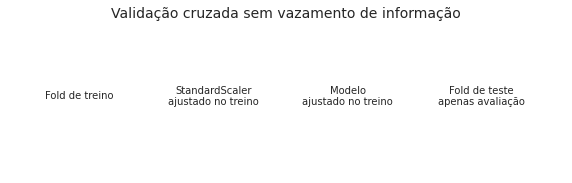

In [ ]:
# Esquema de pipeline dentro da validação cruzada
fig, ax = plt.subplots(figsize=(10, 2.8))
ax.axis("off")

etapas = [
    (0.04, "Fold de treino"),
    (0.28, "StandardScaler\najustado no treino"),
    (0.52, "Modelo\najustado no treino"),
    (0.76, "Fold de teste\napenas avaliação")
]

for x, texto in etapas:
    rect = plt.Rectangle((x, 0.35), 0.18, 0.35, fill=False, linewidth=2)
    ax.add_patch(rect)
    ax.text(x + 0.09, 0.525, texto, ha="center", va="center", fontsize=10)

for x in [0.22, 0.46, 0.70]:
    ax.annotate("", xy=(x + 0.04, 0.525), xytext=(x, 0.525), arrowprops=dict(arrowstyle="->", lw=2))

plt.title("Validação cruzada sem vazamento de informação", fontsize=14)
plt.show()


# 15. Validação cruzada e inferência em modelos estatísticos

Em modelos estatísticos, a validação não substitui a análise dos pressupostos, mas a complementa.

Alguns cuidados importantes:

- **Separação treino-teste:** avalia capacidade preditiva em dados novos.
- **Validação cruzada:** reduz a dependência de uma única partição.
- **Resíduos:** em regressão, ajudam a verificar padrões não capturados pelo modelo.
- **Diagnóstico de influência:** identifica observações com grande impacto no ajuste.
- **Validação temporal:** em séries temporais, não se deve embaralhar o tempo; o treino deve ocorrer antes do teste.
- **Validação externa:** quando possível, o modelo deve ser avaliado em dados coletados em outro contexto, local ou período.

Portanto, a validação estatística envolve tanto desempenho preditivo quanto coerência com o problema e com os dados.


# 16. Resumo da aula

Nesta aula, vimos que:

- avaliar o modelo nos dados de treinamento produz uma estimativa otimista;
- o método holdout separa dados de treino e teste, mas depende de uma única partição;
- a validação cruzada k-fold calcula o desempenho médio em várias divisões;
- o k-fold estratificado preserva a proporção das classes em cada fold;
- o leave-one-out é um caso extremo em que cada observação é testada individualmente;
- pipelines ajudam a evitar vazamento de informação;
- a validação cruzada permite comparar modelos e escolher hiperparâmetros;
- em modelos estatísticos, a validação preditiva deve ser combinada com análise de pressupostos, diagnóstico e interpretação.

A validação é uma etapa essencial para estimar o desempenho real de um modelo e reduzir decisões baseadas em resultados acidentais de uma única amostra ou partição.


# Exercícios sugeridos

1. Altere o percentual de teste no método holdout para 20%, 30% e 40%. O resultado muda muito?
2. Repita a validação cruzada usando `n_splits = 5` e `n_splits = 10`. Compare a média e o desvio padrão.
3. Teste outros valores de `n_neighbors` no KNN.
4. Compare o KNN com outro classificador de sua escolha.
5. Use a função `cross_validate` para calcular também o tempo médio de treinamento.
6. Remova a padronização do pipeline do KNN. O resultado muda?
7. Explique por que a estratificação é importante em problemas com classes desbalanceadas.
